# Module 05 — Linear Models

Linear models are where you should build your deepest intuition, for three
reasons. They are the only family where you can see the entire mechanism.
They remain the regulatory default in credit, insurance and pricing. And every
concept that matters later — regularisation, the loss/penalty distinction,
convexity, the bias–variance trade — is visible here in closed form before it
gets buried inside an ensemble.

We will build ordinary least squares and logistic regression from scratch,
check them against scikit-learn to the seventh decimal, and then work through
the family systematically.

### Learning objectives

1. Derive and implement OLS (normal equations *and* gradient descent) and
   logistic regression, and match `sklearn` numerically.
2. Explain what L1 and L2 penalties do geometrically, and why one produces
   exact zeros.
3. Choose a solver deliberately.
4. Read coefficients as odds ratios, and know when that reading is invalid.
5. Use GLMs (Poisson, Gamma, Tweedie) where the target's distribution demands
   it — the insurance case.
6. Recognise what multicollinearity does to coefficients but not to
   predictions.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, load_insurance_claims, set_plot_style

set_plot_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

## 1. OLS from scratch

The model is `ŷ = Xw + b`. The loss is `L(w) = ‖y − Xw‖²`. Setting the
gradient to zero gives the **normal equations**:

$$ \hat{w} = (X^\top X)^{-1} X^\top y $$

Three implementations, one answer.

In [2]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

X, y = make_regression(n_samples=500, n_features=8, noise=10.0, bias=25.0, random_state=0)


def ols_normal_equations(X, y):
    """Textbook closed form. Numerically fragile if X'X is ill-conditioned."""
    Xb = np.c_[np.ones(len(X)), X]                       # prepend intercept column
    w = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y
    return w[0], w[1:]


def ols_lstsq(X, y):
    """What sklearn actually does: a least-squares solve via SVD.
    It never forms X'X, so it does not square the condition number and it
    returns an answer where the closed form would raise or produce garbage."""
    Xb = np.c_[np.ones(len(X)), X]
    w, *_ = np.linalg.lstsq(Xb, y, rcond=None)
    return w[0], w[1:]


def ols_gradient_descent(X, y, lr=0.05, n_iter=4000):
    """The optimisation view. Slower here, but it is the only one that
    generalises to losses with no closed form (which is all of them)."""
    n, p = X.shape
    Xc, mu = X - X.mean(0), X.mean(0)                    # centring speeds convergence enormously
    w, b = np.zeros(p), y.mean()
    history = []
    for _ in range(n_iter):
        resid = Xc @ w + b - y
        grad_w = (2 / n) * Xc.T @ resid
        grad_b = (2 / n) * resid.sum()
        w -= lr * grad_w
        b -= lr * grad_b
        history.append((resid**2).mean())
    return b - w @ mu, w, np.array(history)


b1, w1 = ols_normal_equations(X, y)
b2, w2 = ols_lstsq(X, y)
b3, w3, hist = ols_gradient_descent(X, y)
sk = LinearRegression().fit(X, y)

print(f"{'method':<26}{'intercept':>12}   first three coefficients")
for name, b, w in [("normal equations", b1, w1), ("lstsq (SVD)", b2, w2),
                   ("gradient descent", b3, w3), ("sklearn", sk.intercept_, sk.coef_)]:
    print(f"{name:<26}{b:>12.6f}   {np.round(w[:3], 6)}")

print(f"\nmax |sklearn − normal equations| : {np.abs(sk.coef_ - w1).max():.2e}")
print(f"max |sklearn − gradient descent| : {np.abs(sk.coef_ - w3).max():.2e}")

method                       intercept   first three coefficients
normal equations             24.953628   [56.405123 68.571869 58.186091]
lstsq (SVD)                  24.953628   [56.405123 68.571869 58.186091]
gradient descent             24.953628   [56.405123 68.571869 58.186091]
sklearn                      24.953628   [56.405123 68.571869 58.186091]

max |sklearn − normal equations| : 7.82e-14
max |sklearn − gradient descent| : 1.21e-13


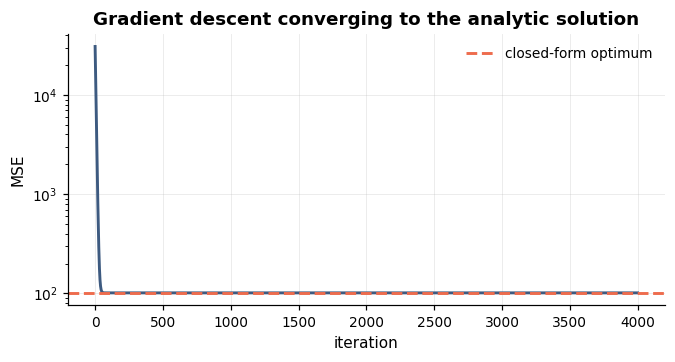

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(hist)
ax.axhline(np.mean((sk.predict(X) - y) ** 2), ls="--", color="#ee6c4d", label="closed-form optimum")
ax.set(yscale="log", xlabel="iteration", ylabel="MSE", title="Gradient descent converging to the analytic solution")
ax.legend()

### Why sklearn uses `lstsq` and not the normal equations

`(XᵀX)⁻¹` squares the condition number of `X`. With correlated features that
is the difference between an answer and noise.

In [4]:
# Two nearly identical columns.
x1 = rng.normal(size=400)
X_ill = np.c_[x1, x1 + rng.normal(scale=1e-7, size=400), rng.normal(size=400)]
y_ill = 3 * x1 + rng.normal(scale=0.1, size=400)

print(f"condition number of X   : {np.linalg.cond(X_ill):.2e}")
print(f"condition number of X'X : {np.linalg.cond(X_ill.T @ X_ill):.2e}   <- squared")

try:
    b_ne, w_ne = ols_normal_equations(X_ill, y_ill)
    print(f"\nnormal equations coefs : {np.round(w_ne, 3)}")
except np.linalg.LinAlgError as e:
    print("\nnormal equations       : LinAlgError —", e)

print(f"sklearn (lstsq) coefs  : {np.round(LinearRegression().fit(X_ill, y_ill).coef_, 3)}")
print(f"Ridge(alpha=1.0) coefs : {np.round(__import__('sklearn.linear_model', fromlist=['Ridge']).Ridge(alpha=1.0).fit(X_ill, y_ill).coef_, 3)}")

condition number of X   : 1.99e+07
condition number of X'X : 3.93e+14   <- squared

normal equations coefs : [-5.7492268e+04  5.7495286e+04 -2.0000000e-03]
sklearn (lstsq) coefs  : [-6.1888135e+04  6.1891136e+04 -2.0000000e-03]
Ridge(alpha=1.0) coefs : [ 1.499  1.499 -0.002]


Both unpenalised solutions put coefficients of order ±60,000 on the two
near-identical columns — enormous, opposite, and cancelling. They are not
wrong (the predictions are fine), they are *arbitrary*: the data cannot
distinguish between "+60,000 and −60,000" and "+1.5 and +1.5". `Ridge` picks
the second, because among all solutions that fit equally well it prefers the
one with the smallest norm.

**That is the single best one-sentence description of what L2 does: it
resolves the ambiguity that collinearity creates.** Note also that `lstsq`
and the normal equations disagree with each other by thousands — when the
answer is that unstable, "which algorithm" starts to matter.

## 2. Logistic regression from scratch

Same skeleton, different loss. We model the **log-odds** as linear:

$$ \log\frac{p}{1-p} = Xw + b \quad\Longleftrightarrow\quad p = \sigma(Xw + b) $$

and minimise the negative log-likelihood. There is no closed form, so we
optimise. The gradient is beautifully simple — identical in form to OLS:

$$ \nabla_w = \tfrac{1}{n} X^\top (\sigma(Xw+b) - y) $$

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


def sigmoid(z):
    # numerically stable form: avoids overflow for large |z|
    out = np.empty_like(z, dtype=float)
    pos, neg = z >= 0, z < 0
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1 + ez)
    return out


def logreg_gd(X, y, lr=0.5, n_iter=6000, l2=0.0):
    n, p = X.shape
    w, b = np.zeros(p), 0.0
    losses = []
    for _ in range(n_iter):
        z = X @ w + b
        pr = sigmoid(z)
        err = pr - y
        w -= lr * ((X.T @ err) / n + l2 * w / n)
        b -= lr * err.mean()
        eps = 1e-12
        losses.append(-np.mean(y * np.log(pr + eps) + (1 - y) * np.log(1 - pr + eps)))
    return w, b, np.array(losses)


credit = load_credit_risk()
num_cols = ["age", "annual_income", "loan_amount", "interest_rate", "debt_to_income", "credit_score", "n_delinq_2yr"]
sub = credit[num_cols + ["default"]].dropna()
Xc = StandardScaler().fit_transform(sub[num_cols])
yc = sub["default"].to_numpy()

w_mine, b_mine, losses = logreg_gd(Xc, yc)

# sklearn with C -> infinity is unpenalised, matching our l2=0 implementation.
sk_lr = LogisticRegression(penalty=None, max_iter=5000).fit(Xc, yc)

comparison = pd.DataFrame(
    {"from scratch": w_mine, "sklearn": sk_lr.coef_.ravel()}, index=num_cols
).round(5)
comparison["abs diff"] = (comparison["from scratch"] - comparison["sklearn"]).abs().round(6)
print(f"intercept: mine {b_mine:.5f}  |  sklearn {sk_lr.intercept_[0]:.5f}\n")
comparison

intercept: mine -2.30029  |  sklearn -2.30216



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,from scratch,sklearn,abs diff
age,0.05067,0.04989,0.00078
annual_income,-0.03790,-0.04079,0.00289
loan_amount,0.02431,0.02699,0.00268
interest_rate,0.06739,0.06762,0.00023
debt_to_income,0.47317,0.47281,0.00036
credit_score,-0.74691,-0.74731,0.00040
n_delinq_2yr,0.12107,0.12101,0.00006


[Text(0.5, 0, 'iteration'),
 Text(0, 0.5, 'mean log-loss'),
 Text(0.5, 1.0, 'Logistic regression: negative log-likelihood')]

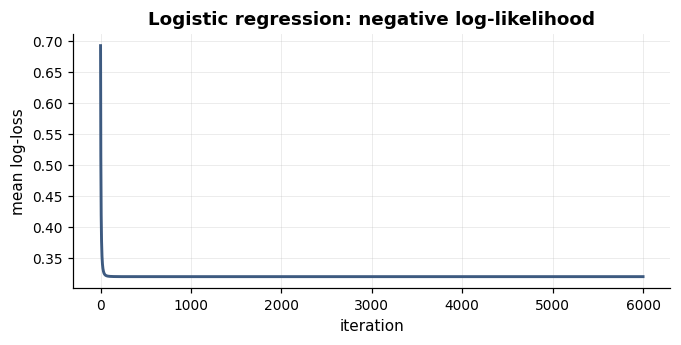

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses)
ax.set(xlabel="iteration", ylabel="mean log-loss", title="Logistic regression: negative log-likelihood")

### Coefficients as odds ratios

Because the model is linear in log-odds, `exp(w_j)` is the **multiplicative
effect on the odds** of a one-unit increase in feature *j*. This is why
logistic regression survives in regulated settings: the sentence "a one
standard-deviation increase in debt-to-income multiplies the odds of default
by 1.4" is auditable in a way that a SHAP value is not.

Two conditions on that reading, both routinely violated:

1. **The features must be scaled** (or you must state the unit), or the
   coefficients are not comparable to each other.
2. **The interpretation is conditional on all other features being held
   fixed** — which is not a thing that happens in the world when features are
   correlated.

In [7]:
odds = pd.DataFrame(
    {
        "coefficient": sk_lr.coef_.ravel(),
        "odds_ratio": np.exp(sk_lr.coef_.ravel()),
    },
    index=num_cols,
).sort_values("coefficient", key=np.abs, ascending=False).round(4)
odds["reading"] = [
    f"+1 s.d. → odds ×{r:.2f}" for r in odds["odds_ratio"]
]
odds

,coefficient,odds_ratio,reading
credit_score,-0.7473,0.4736,+1 s.d. → odds ×0.47
debt_to_income,0.4728,1.6045,+1 s.d. → odds ×1.60
n_delinq_2yr,0.1210,1.1286,+1 s.d. → odds ×1.13
interest_rate,0.0676,1.0700,+1 s.d. → odds ×1.07
age,0.0499,1.0512,+1 s.d. → odds ×1.05
annual_income,-0.0408,0.9600,+1 s.d. → odds ×0.96
loan_amount,0.0270,1.0274,+1 s.d. → odds ×1.03


## 3. The loss × penalty grid

Almost every estimator in `sklearn.linear_model` is a cell in one table:

| | **no penalty** | **L2 (ridge)** | **L1 (lasso)** | **L1+L2 (elastic net)** |
|---|---|---|---|---|
| **squared error** | `LinearRegression` | `Ridge` | `Lasso` | `ElasticNet` |
| **log loss** | `LogisticRegression(penalty=None)` | `LogisticRegression` (default) | `LogisticRegression(penalty="l1")` | `LogisticRegression(penalty="elasticnet")` |
| **hinge** | — | `LinearSVC` | — | — |
| **epsilon-insensitive** | — | `LinearSVR` | — | — |
| **Huber** | — | `HuberRegressor` | — | — |
| **Poisson / Gamma / Tweedie deviance** | — | `PoissonRegressor` etc. | — | — |
| **pinball (quantile)** | — | — | `QuantileRegressor` | — |

`SGDClassifier` / `SGDRegressor` let you pick the loss *and* the penalty
independently, which makes them the general case of this whole table — at the
cost of needing to tune a learning-rate schedule.

**Learn the table, not the forty class names.**

### What L1 and L2 actually do

Both add a penalty on coefficient size. The difference is the shape of the
constraint region, and that shape is why one produces exact zeros.

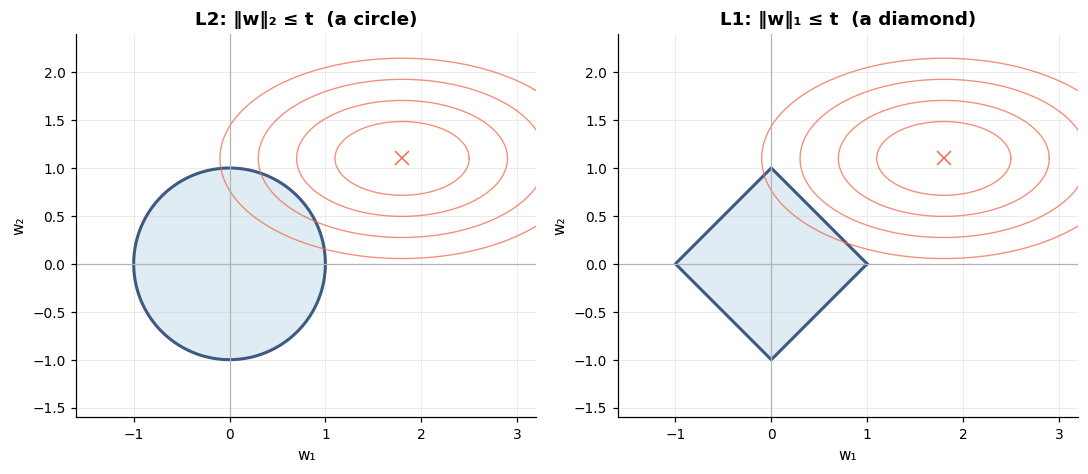

In [8]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

# Constraint-region picture in 2-D.
theta = np.linspace(0, 2 * np.pi, 400)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, (name, xs, ys) in zip(
    axes,
    [
        ("L2: ‖w‖₂ ≤ t  (a circle)", np.cos(theta), np.sin(theta)),
        ("L1: ‖w‖₁ ≤ t  (a diamond)", np.r_[1, 0, -1, 0, 1], np.r_[0, 1, 0, -1, 0]),
    ],
):
    ax.plot(xs, ys, color="#3d5a80", lw=2)
    ax.fill(xs, ys, color="#98c1d9", alpha=0.3)
    # elliptical contours of the unpenalised loss, centred away from the origin
    for r in [0.7, 1.1, 1.5, 1.9]:
        ax.plot(1.8 + r * 1.0 * np.cos(theta), 1.1 + r * 0.55 * np.sin(theta), color="#ee6c4d", lw=0.9, alpha=0.75)
    ax.plot(1.8, 1.1, "x", color="#ee6c4d", ms=9)
    ax.axhline(0, color="0.7", lw=0.8); ax.axvline(0, color="0.7", lw=0.8)
    ax.set(xlim=(-1.6, 3.2), ylim=(-1.6, 2.4), title=name, aspect="equal")
    ax.set_xlabel("w₁"); ax.set_ylabel("w₂")
plt.tight_layout()

The solution is where the loss contours first touch the constraint region.
A circle has no corners, so the touch point almost never has a coordinate
exactly zero. A diamond has corners **on the axes**, and corners are where
expanding contours tend to make first contact — so L1 solutions land on zeros.
That is the entire geometric argument for why lasso selects features and ridge
does not.

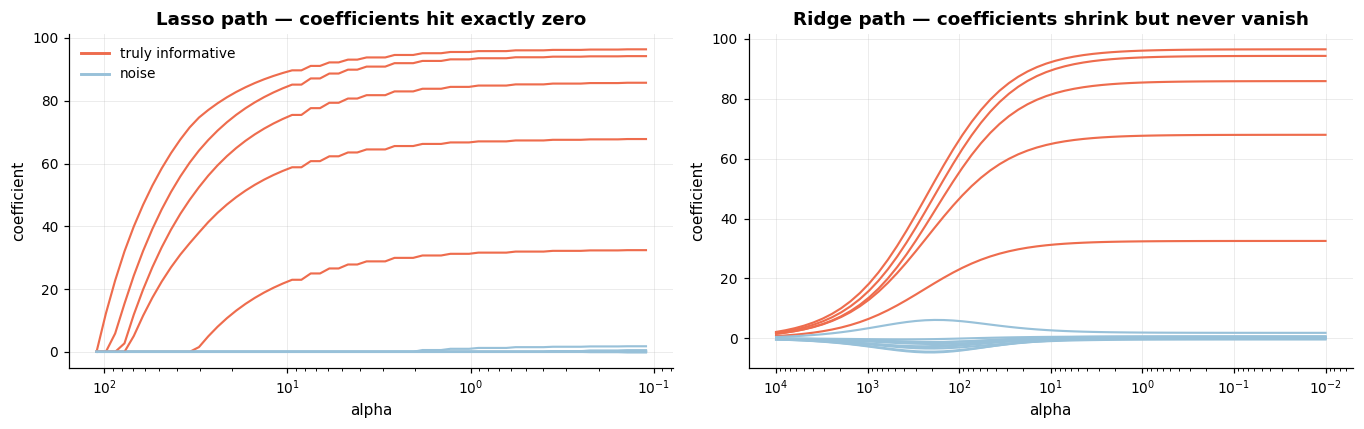

In [9]:
# The regularisation path makes it concrete.
from sklearn.linear_model import lasso_path

X_reg, y_reg, coef_true = make_regression(n_samples=200, n_features=15, n_informative=5, noise=8, coef=True, random_state=1)
X_reg = StandardScaler().fit_transform(X_reg)

alphas_l1, coefs_l1, _ = lasso_path(X_reg, y_reg, n_alphas=60)
alphas_l2 = np.logspace(-2, 4, 60)
coefs_l2 = np.array([Ridge(alpha=a).fit(X_reg, y_reg).coef_ for a in alphas_l2]).T

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
for ax, alphas, coefs, name in [
    (axes[0], alphas_l1, coefs_l1, "Lasso path — coefficients hit exactly zero"),
    (axes[1], alphas_l2, coefs_l2, "Ridge path — coefficients shrink but never vanish"),
]:
    for j in range(coefs.shape[0]):
        ax.plot(alphas, coefs[j], lw=1.4, color="#ee6c4d" if coef_true[j] != 0 else "#98c1d9")
    ax.set(xscale="log", xlabel="alpha", ylabel="coefficient", title=name)
    ax.invert_xaxis()
axes[0].plot([], [], color="#ee6c4d", label="truly informative")
axes[0].plot([], [], color="#98c1d9", label="noise")
axes[0].legend()
plt.tight_layout()

In [10]:
# Counting exact zeros makes it unambiguous.
pd.DataFrame(
    {
        "alpha": [0.01, 0.1, 1.0, 5.0],
        "lasso_nonzero": [int((Lasso(alpha=a).fit(X_reg, y_reg).coef_ != 0).sum()) for a in [0.01, 0.1, 1.0, 5.0]],
        "ridge_nonzero": [int((Ridge(alpha=a).fit(X_reg, y_reg).coef_ != 0).sum()) for a in [0.01, 0.1, 1.0, 5.0]],
        "elasticnet_nonzero": [int((ElasticNet(alpha=a, l1_ratio=0.5).fit(X_reg, y_reg).coef_ != 0).sum()) for a in [0.01, 0.1, 1.0, 5.0]],
    }
).set_index("alpha")

,lasso_nonzero,ridge_nonzero,elasticnet_nonzero
alpha,,,
0.01,15,15,15
0.10,14,15,14
1.00,6,15,14
5.00,5,15,14


### The `alpha` / `C` inversion

A recurring source of confusion: **regressors take `alpha` (bigger = more
regularisation); classifiers take `C` (bigger = *less* regularisation).**
`C ≈ 1/alpha`. This is inherited from the SVM literature and it will not
change. Write it on a sticky note.

## 4. Solvers

`LogisticRegression` has five. The choice is usually invisible and
occasionally decisive.

| Solver | Penalties | Multiclass | Sparse X | Best for |
|---|---|---|---|---|
| `lbfgs` (default) | L2, none | multinomial | ✓ | the default; small–medium dense data |
| `liblinear` | L1, L2 | one-vs-rest only | ✓ | small data, L1, binary |
| `newton-cg` | L2, none | multinomial | ✓ | when lbfgs struggles |
| `newton-cholesky` | L2, none | multinomial | ✗ | **n_samples ≫ n_features**; very fast |
| `saga` | L1, L2, elasticnet, none | multinomial | ✓ | large n, elastic net, sparse |

The two that matter in practice: `newton-cholesky` when you have millions of
rows and few columns (a very common tabular shape), and `saga` when you need
elastic net or have huge sparse text features.

In [11]:
from time import perf_counter

from sklearn.datasets import make_classification

X_big, y_big = make_classification(n_samples=60_000, n_features=25, n_informative=12, random_state=0)
X_big = StandardScaler().fit_transform(X_big)

timings = []
for solver in ["lbfgs", "newton-cg", "newton-cholesky", "saga"]:
    t0 = perf_counter()
    m = LogisticRegression(solver=solver, max_iter=400).fit(X_big, y_big)
    timings.append({"solver": solver, "seconds": round(perf_counter() - t0, 3),
                    "train_acc": round(m.score(X_big, y_big), 4),
                    "n_iter": int(np.ravel(m.n_iter_)[0])})
pd.DataFrame(timings).set_index("solver")

,seconds,train_acc,n_iter
solver,,,
lbfgs,0.080,0.7265,10
newton-cg,0.119,0.7265,4
newton-cholesky,0.044,0.7265,4
saga,0.318,0.7265,17


Same answer to four decimal places, order-of-magnitude different runtimes.
When someone says "the logistic regression takes twenty minutes to fit", the
solver is the first thing to look at.

## 5. Robust regression: when squared error is the wrong question

Squared error weights an error of 10 a hundred times more than an error of 1.
One mis-keyed data-entry value can therefore dominate a fit. Four alternatives,
each with a different theory of what an outlier is.

,slope,true_slope
model,,
LinearRegression,2.439,2.5
HuberRegressor,2.480,2.5
RANSACRegressor,2.463,2.5
TheilSenRegressor,2.499,2.5
QuantileRegressor(0.5),2.487,2.5


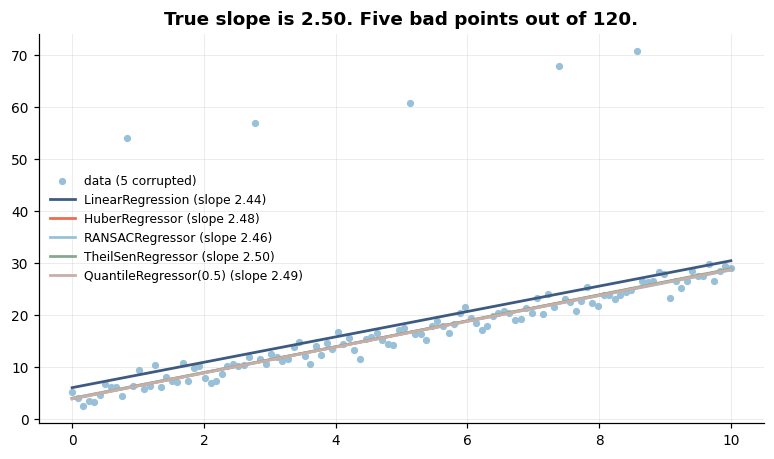

In [12]:
from sklearn.linear_model import HuberRegressor, QuantileRegressor, RANSACRegressor, TheilSenRegressor

x = np.linspace(0, 10, 120)
y_clean = 2.5 * x + 4 + rng.normal(0, 1.2, 120)
y_dirty = y_clean.copy()
y_dirty[[10, 33, 61, 88, 102]] += 45          # five data-entry errors
Xr = x.reshape(-1, 1)

models = {
    "LinearRegression": LinearRegression(),
    "HuberRegressor": HuberRegressor(epsilon=1.35),
    "RANSACRegressor": RANSACRegressor(random_state=0),
    "TheilSenRegressor": TheilSenRegressor(random_state=0),
    "QuantileRegressor(0.5)": QuantileRegressor(quantile=0.5, alpha=0),
}

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(x, y_dirty, s=14, color="#98c1d9", label="data (5 corrupted)")
rows = []
for name, m in models.items():
    m.fit(Xr, y_dirty)
    slope = m.estimator_.coef_[0] if hasattr(m, "estimator_") else np.ravel(m.coef_)[0]
    ax.plot(x, m.predict(Xr), lw=1.8, label=f"{name} (slope {slope:.2f})")
    rows.append({"model": name, "slope": round(float(slope), 3), "true_slope": 2.5})
ax.legend(fontsize=8)
ax.set_title("True slope is 2.50. Five bad points out of 120.")
pd.DataFrame(rows).set_index("model")

How each one thinks:

- **Huber** — squared error near zero, linear in the tails. Downweights
  outliers rather than excluding them. The safe general choice.
- **RANSAC** — repeatedly fits on random minimal subsets and keeps the model
  with the most inliers. Excellent when outliers are a large fraction; can be
  unstable when they are not.
- **Theil–Sen** — the median of pairwise slopes. Very robust, but scales
  badly (it is `O(n²)` in the number of pairs it samples).
- **Quantile** — minimises pinball loss, so it models a *quantile* rather than
  the mean. `quantile=0.5` is median regression; `quantile=0.9` gives you a
  conditional 90th percentile, which is how you build prediction intervals
  from a linear model.

Text(0.5, 1.0, 'Conditional quantiles — a prediction interval, not a point estimate')

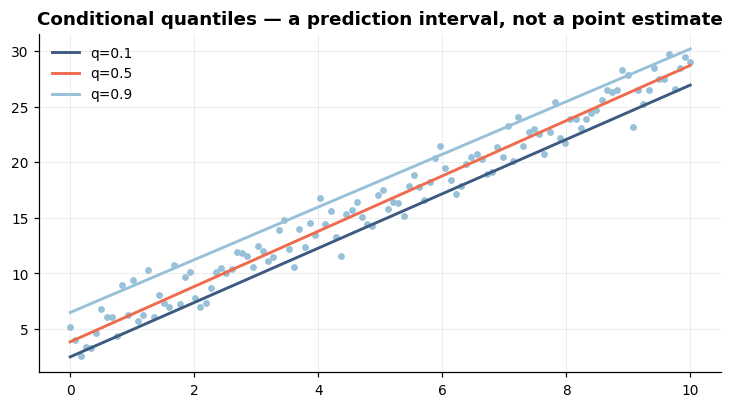

In [13]:
# Quantile regression's real use: intervals, not robustness.
qs = [0.1, 0.5, 0.9]
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y_clean, s=12, color="#98c1d9")
for q in qs:
    qr = QuantileRegressor(quantile=q, alpha=0).fit(Xr, y_clean)
    ax.plot(x, qr.predict(Xr), label=f"q={q}")
ax.legend(); ax.set_title("Conditional quantiles — a prediction interval, not a point estimate")

## 6. GLMs: matching the loss to the target's distribution

The insurance claims dataset is the canonical case. `claim_cost` is:
non-negative, **91% exactly zero**, and heavy-tailed on the non-zero part.
Squared error assumes a symmetric, constant-variance Gaussian. None of those
things are true.

91.0% of policies have zero claims
count    15000.0
mean       123.0
std        528.5
min          0.0
50%          0.0
90%          0.0
99%       2724.7
max      13970.1


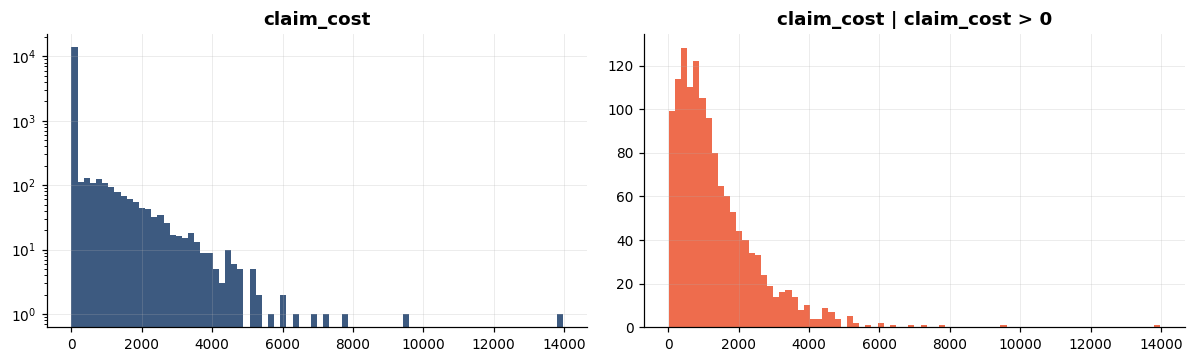

In [14]:
claims = load_insurance_claims()
print(f"{(claims.claim_cost == 0).mean():.1%} of policies have zero claims")
print(claims["claim_cost"].describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(claims["claim_cost"], bins=80, color="#3d5a80")
axes[0].set(title="claim_cost", yscale="log")
axes[1].hist(claims.loc[claims.claim_cost > 0, "claim_cost"], bins=80, color="#ee6c4d")
axes[1].set(title="claim_cost | claim_cost > 0")
plt.tight_layout()

### The three GLM families sklearn ships

| Estimator | Target | `power` | Use for |
|---|---|---|---|
| `PoissonRegressor` | counts, ≥ 0 | 1 | claim **frequency**, number of events |
| `GammaRegressor` | positive, right-skewed | 2 | claim **severity** given a claim |
| `TweedieRegressor` | ≥ 0 with a mass at zero | 1 < p < 2 | **pure premium** — frequency × severity in one model |

All use a log link by default, so predictions are guaranteed non-negative and
coefficients are multiplicative — which is exactly how insurance rating
factors are expressed and regulated.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import GammaRegressor, PoissonRegressor, TweedieRegressor
from sklearn.metrics import mean_absolute_error, mean_poisson_deviance, mean_tweedie_deviance
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

feat_cols = ["driver_age", "vehicle_age", "vehicle_power", "bonus_malus", "annual_mileage", "area", "fuel", "coverage"]
Xi = claims[feat_cols]
tr, te = train_test_split(np.arange(len(claims)), test_size=0.25, random_state=0)

prep = ColumnTransformer(
    [
        ("num", StandardScaler(), ["driver_age", "vehicle_age", "vehicle_power", "bonus_malus", "annual_mileage"]),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), ["area", "fuel", "coverage"]),
    ]
)

# --- Frequency: Poisson, with exposure as a sample weight ------------------
freq_model = Pipeline([("prep", prep), ("glm", PoissonRegressor(alpha=1e-3, max_iter=500))])
freq_model.fit(Xi.iloc[tr], claims["claim_count"].iloc[tr] / claims["exposure"].iloc[tr],
               glm__sample_weight=claims["exposure"].iloc[tr])
pred_freq = freq_model.predict(Xi.iloc[te])

print(f"Poisson deviance (frequency): "
      f"{mean_poisson_deviance(claims['claim_count'].iloc[te] / claims['exposure'].iloc[te], pred_freq, sample_weight=claims['exposure'].iloc[te]):.4f}")

Poisson deviance (frequency): 0.6086


Note `sample_weight=exposure`. A policy in force for three months is a
quarter of the evidence of one in force for a year, and the Poisson likelihood
handles that natively through the weight. Modelling `claim_count` directly and
ignoring exposure is one of the most common errors in insurance pricing work.

In [16]:
# --- Pure premium: Tweedie handles the zero mass directly ------------------
y_pp = claims["claim_cost"] / claims["exposure"]

rows = []
for name, est in [
    ("Ridge (squared error)", Ridge(alpha=1.0)),
    ("Tweedie p=1.3", TweedieRegressor(power=1.3, alpha=1e-3, max_iter=800)),
    ("Tweedie p=1.5", TweedieRegressor(power=1.5, alpha=1e-3, max_iter=800)),
    ("Tweedie p=1.7", TweedieRegressor(power=1.7, alpha=1e-3, max_iter=800)),
]:
    pipe = Pipeline([("prep", prep), ("glm", est)])
    pipe.fit(Xi.iloc[tr], y_pp.iloc[tr], glm__sample_weight=claims["exposure"].iloc[tr])
    pred = pipe.predict(Xi.iloc[te])
    rows.append(
        {
            "model": name,
            "negative_preds": int((pred < 0).sum()),
            "MAE": round(mean_absolute_error(y_pp.iloc[te], pred, sample_weight=claims["exposure"].iloc[te]), 2),
            "tweedie_dev_1.5": round(mean_tweedie_deviance(y_pp.iloc[te], np.clip(pred, 1e-6, None), power=1.5,
                                                          sample_weight=claims["exposure"].iloc[te]), 2),
            "total_pred/actual": round(float(np.average(pred, weights=claims["exposure"].iloc[te]) /
                                             np.average(y_pp.iloc[te], weights=claims["exposure"].iloc[te])), 3),
        }
    )
pd.DataFrame(rows).set_index("model")

,negative_preds,MAE,tweedie_dev_1.5,total_pred/actual
model,,,,
Ridge (squared error),329,309.79,24983.52,0.891
Tweedie p=1.3,0,301.49,72.73,0.889
Tweedie p=1.5,0,301.49,72.80,0.887
Tweedie p=1.7,0,301.39,72.86,0.885


Read the `negative_preds` column first. `Ridge` predicts **negative claim
costs** for several hundred policies — a nonsensical output that no amount of
error-metric tuning fixes, because the model class permits it. Every Tweedie
model predicts zero or positive by construction, because of the log link. Note
also the Tweedie deviance column: `Ridge` scores ~300× worse on the metric
that matches the target's actual distribution, while looking merely a few
percent worse on MAE. Choosing the metric is choosing what you can see.

The `total_pred/actual` column is the one an actuary looks at. **All four
models come in around 0.89 — they under-predict the portfolio total by ~11%,
and that is a finding, not a rounding error.** The log-link balance property
holds on the *training* data of an unpenalised GLM; here we regularised
(`alpha=1e-3`) and are scoring a held-out sample, so the guarantee does not
transfer. In a real pricing exercise you would either re-base the model to the
portfolio total or drop the penalty and check the balance again — and you
would only notice the problem because you computed this column. Diagnose the
ratio; do not assume it.

> 💼 **Consulting lens.** "Which model has the lowest RMSE" is the wrong first
> question in insurance pricing. The right ones are: does it predict
> non-negative values, does it balance to the portfolio total, and are the
> rating factors multiplicative and explainable. A model can win on RMSE and
> be unimplementable.

## 7. Multicollinearity: what it breaks and what it does not

When features are correlated, the coefficient estimates become unstable — but
the *predictions* are usually fine. Knowing which of the two you need
determines whether you should care.

In [17]:
from sklearn.model_selection import cross_val_score

base = rng.normal(size=(300, 1))
X_col = np.c_[base, base * 0.98 + rng.normal(scale=0.02, size=(300, 1)), rng.normal(size=(300, 2))]
y_col = (3 * X_col[:, 0] + rng.normal(scale=0.5, size=300))

coef_runs, pred_runs = [], []
for seed in range(12):
    idx = np.random.default_rng(seed).choice(300, 250, replace=False)
    m = LinearRegression().fit(X_col[idx], y_col[idx])
    coef_runs.append(m.coef_[:2])
    pred_runs.append(m.predict(X_col[:5]))

coef_runs, pred_runs = np.array(coef_runs), np.array(pred_runs)
print("Across 12 bootstrap resamples:")
print(f"  coefficient 0 : mean {coef_runs[:, 0].mean():7.2f}  std {coef_runs[:, 0].std():6.2f}")
print(f"  coefficient 1 : mean {coef_runs[:, 1].mean():7.2f}  std {coef_runs[:, 1].std():6.2f}")
print(f"  sum of the two: mean {coef_runs.sum(1).mean():7.2f}  std {coef_runs.sum(1).std():6.2f}   <- stable!")
print(f"  predictions   : mean std across runs {pred_runs.std(0).mean():.4f}   <- stable")

Across 12 bootstrap resamples:
  coefficient 0 : mean    2.13  std   0.63
  coefficient 1 : mean    0.90  std   0.64
  sum of the two: mean    3.03  std   0.02   <- stable!
  predictions   : mean std across runs 0.0229   <- stable


The individual coefficients swing wildly; their **sum** and the
**predictions** are rock solid. The model does not know how to allocate credit
between two identical features, and it does not need to in order to predict.

The consequences:

- If you need **prediction**, collinearity is mostly a non-issue. Regularise
  and move on.
- If you need **inference or explanation** — "which factor drives default?",
  a regulatory model narrative, a feature-importance story — collinearity
  makes the answer arbitrary, and reporting one of the two coefficients as
  *the* effect is misleading.

`VIF` (variance inflation factor) is the standard diagnostic; a correlation
heatmap plus `Ridge` is the standard mitigation.

In [18]:
# A quick VIF, without pulling in statsmodels.
def vif(X: pd.DataFrame) -> pd.Series:
    out = {}
    for col in X.columns:
        others = X.drop(columns=col)
        r2 = LinearRegression().fit(others, X[col]).score(others, X[col])
        out[col] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(out, name="VIF").sort_values(ascending=False)


num_frame = credit[num_cols].dropna()
vif(num_frame).round(2).to_frame()

,VIF
interest_rate,2.77
annual_income,2.43
credit_score,2.41
loan_amount,2.32
debt_to_income,1.90
age,1.32
n_delinq_2yr,1.03


Rule of thumb: VIF > 5 is worth a look, VIF > 10 means the coefficient is not
interpretable on its own.

---
## Exercises

### Exercise 5.1 — Ridge from scratch, two ways

1. Derive and implement the closed form `w = (XᵀX + αI)⁻¹Xᵀy`. Be careful not
   to penalise the intercept.
2. Implement ridge by gradient descent.
3. Match `sklearn.linear_model.Ridge` to 1e-8 for `alpha ∈ {0.1, 1, 100}`.
4. Show empirically that as `alpha → 0` you recover OLS, and as `alpha → ∞`
   every coefficient → 0 and predictions → `y.mean()`.

In [19]:
# Your code here.

### Exercise 5.2 — Implement coordinate descent for Lasso

Gradient descent cannot produce exact zeros because the L1 gradient is
undefined at zero. Coordinate descent can, using the soft-threshold operator
`S(z, γ) = sign(z)·max(|z| − γ, 0)`.

Implement it, verify against `sklearn.linear_model.Lasso` (use
`fit_intercept=False` and pre-standardised features to keep the comparison
clean), and plot your own regularisation path. Confirm your zeros are *exactly*
zero, not 1e-14.

In [20]:
# Your code here.

### Exercise 5.3 — Solver bake-off

Build four datasets: (a) 100k rows × 20 features dense; (b) 1k rows × 5k
features dense; (c) 50k × 30k sparse text-like; (d) 5k × 50 with two perfectly
collinear columns. For each, fit `LogisticRegression` with every compatible
solver and record time, iterations, convergence warnings, and score.

Produce a one-page decision table you would actually use. Where a solver
fails or warns, say why.

In [21]:
# Your code here.

### Exercise 5.4 — A frequency–severity insurance model

Build the classical two-part actuarial model on the claims data:

1. `PoissonRegressor` for claim **frequency**, using `exposure` as
   `sample_weight`.
2. `GammaRegressor` for **severity**, fitted only on policies with
   `claim_count > 0`, using `claim_count` as `sample_weight`.
3. Pure premium = frequency × severity.

Compare that against a single `TweedieRegressor(power=1.5)` on
`claim_cost / exposure`, on: exposure-weighted MAE, Tweedie deviance, the
portfolio total ratio, and a lift chart by predicted-premium decile.
Which would you take to a pricing committee, and why?

In [22]:
# Your code here.

### Exercise 5.5 — Regularisation under collinearity

Create a dataset with 8 features where features 0–2 are near-duplicates of one
signal and 3–7 are noise. Fit `LinearRegression`, `Ridge`, `Lasso` and
`ElasticNet` on 50 bootstrap resamples each and record the coefficient
distributions.

Report: which estimator gives the most stable coefficients; which gives the
most stable *predictions*; and which one you would use if a regulator asked
"which of these three correlated variables is driving the decision?" (There is
a trap in that last question — name it.)

In [23]:
# Your code here.

---
## Takeaways

- You can write OLS and logistic regression in fifteen lines. Do it once and
  the rest of the library stops being mysterious.
- `sklearn` uses `lstsq`/SVD rather than the normal equations because `(XᵀX)⁻¹`
  squares the condition number.
- The library is a **loss × penalty grid**. L1's diamond has corners on the
  axes, which is why it zeroes coefficients; L2's circle does not.
- `alpha` (regressors) and `C` (classifiers) move in opposite directions.
- Solvers change runtime by an order of magnitude and the answer by nothing.
  `newton-cholesky` for tall-thin data; `saga` for sparse or elastic net.
- Match the loss to the target's distribution. Squared error on a
  zero-inflated non-negative target predicts negative values — use Tweedie.
- Collinearity destabilises coefficients, not predictions. Which one you care
  about decides whether it is a problem.

**Next:** Module 06 — trees and ensembles, where interpretability is traded for
accuracy and the trade needs managing.